#### Import libraries and load data

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk

# Set plotting style
sns.set_theme(style="whitegrid")

langs = ['eng', 'zho', 'nld']
datasets = {}

# Load data from the directory we just downloaded to
for lang in langs:
    path = f"../data/raw/{lang}_dataset"
    if os.path.exists(path):
        datasets[lang] = load_from_disk(path)
        print(f"Loaded {lang}: {datasets[lang]['train'].num_rows} documents.")
    else:
        print(f"Path not found: {path}")

Loaded eng: 137710 documents.
Loaded zho: 203891 documents.
Loaded nld: 304611 documents.


#### Extract features and compute statistics 

In [ ]:
# To speed up computation, we randomly sample 10,000 rows from each language for EDA
sample_size = 10000
data_stats = []

for lang, ds in datasets.items():
    # Get the training set and sample
    train_split = ds['train']
    actual_sample_size = min(sample_size, len(train_split))
    sampled_data = train_split.shuffle(seed=42).select(range(actual_sample_size))
    
    for item in sampled_data:
        text = item['text']
        # Simple calculation of character length and rough word count 
        # (characters for ZH, space-separated words for EN/NL)
        char_length = len(text)
        word_count = len(text.split()) if lang != 'zh' else char_length
        
        data_stats.append({
            'Language': lang.upper(),
            'Character Length': char_length,
            'Rough Word Count': word_count
        })

df_stats = pd.DataFrame(data_stats)
display(df_stats.groupby('Language').describe())

Character Length                                               \
                    count       mean           std   min    25%    50%   
Language                                                                 
ENG               10000.0  3819.7640  21583.594051  11.0  178.0  389.0   
NLD               10000.0  2139.0952  22465.853461  17.0  143.0  285.0   
ZHO               10000.0   944.5255   2002.021669   3.0   57.0  302.0   

                             Rough Word Count                              \
              75%        max            count      mean          std  min   
Language                                                                    
ENG       1026.25   744455.0          10000.0  700.2680  3970.596766  3.0   
NLD        521.00  2049911.0          10000.0  409.7520  3637.444628  2.0   
ZHO        724.00    65618.0          10000.0   77.9278   259.318752  1.0   

                                       
           25%   50%    75%       max  
Language                               
ENG       30.0  66.0  173.0  133589.0  
NLD       25.0  50.0   90.0  317894.0  
ZHO        1.0  10.0   23.0    9676.0

#### Visualize length distribution

/var/folders/zm/s3nl0q4959v39_q9fkwm3xvw0000gn/T/ipykernel_93258/4180826010.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats, x='Language', y='Character Length', palette="Set2")


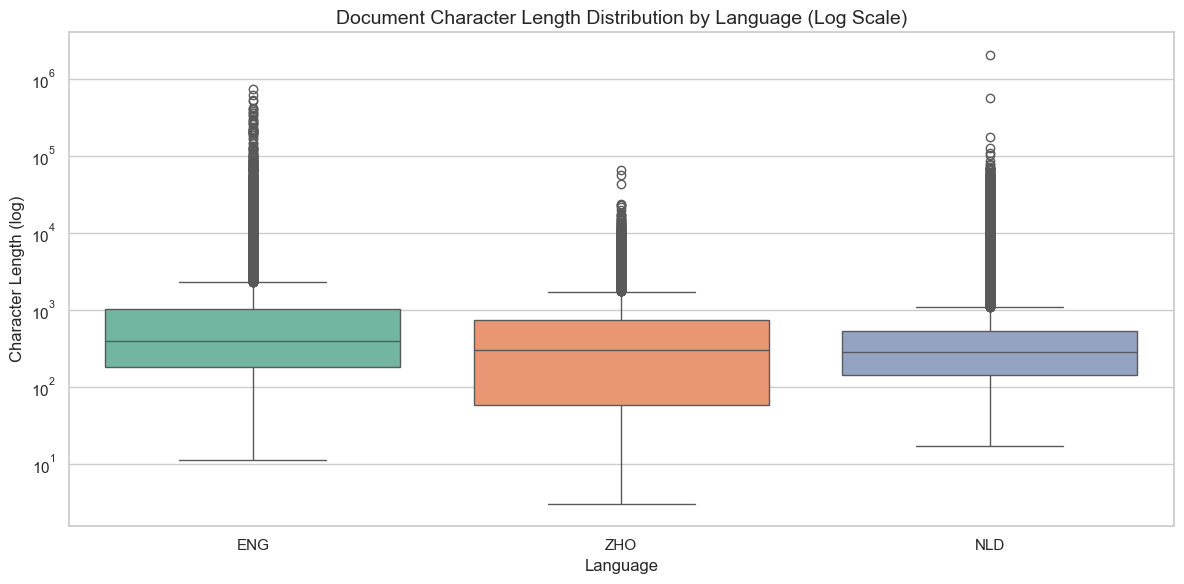

In [3]:
plt.figure(figsize=(12, 6))

# Use a logarithmic scale for character length distribution to handle outliers
sns.boxplot(data=df_stats, x='Language', y='Character Length', palette="Set2")
plt.title("Document Character Length Distribution by Language (Log Scale)", fontsize=14)
plt.yscale('log')
plt.ylabel("Character Length (log)", fontsize=12)
plt.xlabel("Language", fontsize=12)

plt.tight_layout()
plt.show()

#### Inspect the mixed data

In [20]:
import pandas as pd
from datasets import load_from_disk

# Load the Stage 1 data we just mixed
# (假設我們跑的是 10M 測試預算)
stage1_path = "../data/processed_10M/Stage_1_Foundation"
mixed_ds = load_from_disk(stage1_path)

print(f"Total Rows: {len(mixed_ds):,}")

# Convert the first 10 rows to a Pandas DataFrame for easy viewing
df_preview = pd.DataFrame(mixed_ds.select(range(10)))

# Display the preview
print("\n--- Data Preview ---")
display(df_preview)

# Verify if the mixing ratio meets expectations
print("\n--- Row Count by Language ---")
# 注意：這裡是 Row 數量比例，不是 Token 比例。
# 因為英文單字佔的 Row 通常比中文長，所以 Row 比例不會剛好等於 50:25:25，這是正常的！
df_all = pd.DataFrame(mixed_ds)
display(df_all['language'].value_counts(normalize=True).round(4) * 100)

Total Rows: 3,545

--- Data Preview ---


,text,doc-id,category,data-source,script,age-estimate,license,misc,num-tokens,language
0,VRT Canvas\nVRT Canvas (tot 4 september 2023 C...,cc8457c96004456ad8ce392214d23b29b4dea31edfc7d6...,child-wiki,wikikids,Latn,n/a,cc-by-sa,"{""title"": ""Canvas_(televisiezender).txt""}",428,nld
1,TIA\nTIA is een kortdurende afsluiting van een...,d262279e0037a939cbe5e79d14ae66b4e15c6bc54b8716...,child-wiki,wikikids,Latn,n/a,cc-by-sa,"{""title"": ""TIA.txt""}",45,nld
2,...- Amerikaanse ...- Belgische ...- Europese ...,febf35419bce2595d5fae38ee8e83e5ee14ad856b50325...,educational,BasiLex,Latn,n/a,CC-BY-NC,"{""original"": ""0_63_24.xml""}",10,nld
3,Chiba\nChiba is een grote stad in Japan met 96...,7695ae6abfe9b111a0d65b60acb55a53c2a33ff39a83c5...,child-wiki,wikikids,Latn,n/a,cc-by-sa,"{""title"": ""Chiba_(stad).txt""}",274,nld
4,大家好 欢迎打开全民阅读 我是主播童飞 在山东临沂向您问好 如果论当下人们的稀缺品 快乐应当...,X0000028695_201268675,subtitles,WenetSpeech,Hans,n/a,Apache-2.0,{},1223,zho
5,"KOM OP, START! OF MOET JE WEER DWARSLIGGEN, RA...",78fd34245476e3ac0194f607a516c69a59570f397f1e73...,child-books,BasiLex,Latn,10-12,CC-BY-NC,"{""original"": ""5_10_14.xml""}",55,nld
6,AUNT PATTY'S PAYING GUESTS\nTranscriber's note...,3bd76ef7821a5980b9cb8ad308f788221709d824fc54f9...,child-books,Project Gutenberg,Latn,n/a,Project Gutenberg License,{},68313,eng
7,"题干:\n下面句子中划线字的用法与""不如吾闻而药之也""句中""药""字用法相同的两项是\n\n选...",cca6f17ec751bff92feecc1e20866eff33d4e500dfa575...,educational,ck12,Hans,n/a,cc-by-nc-sa-4.0,{},312,zho
8,"妈妈,你给我讲个故事吧。",9b042e96bb8f0a33faf8dbe9809bd7a3d629b416430685...,child-directed-speech,ChildMandarin,Hans,5,CC BY-NC-SA 4.0,{},9,zho
9,"题干:\n下列句子意思不同于其他三项的是\n\n选项:\nA.亲密的伙伴还在一块儿,离不离开...",5bfe30e29dfeb814efa712d89b547bf08509a902bfcf20...,educational,ck12,Hans,n/a,cc-by-nc-sa-4.0,{},140,zho



--- Row Count by Language ---


language
nld    37.91
zho    32.50
eng    29.59
Name: proportion, dtype: float64

#### Qualitative Tokenizer Check

In [17]:
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_file("../tokenizers/tokenizer_100M.json")


# Define some "difficult/high-frequency" test sentences for the three languages
test_sentences = {
    "ENG": [
        "Language modeling is a fascinating subfield of artificial intelligence.",
        "The quick brown fox jumps over the lazy dog.",
        "Unbelievable architectural optimization techniques." # 測試字首字尾拆解
    ],
    "ZHO": [
        "因为我们有强大的计算资源，所以模型训练速度非常快。", # 測試常見連接詞
        "自然语言处理是一个充满挑战的领域。", # 測試專有名詞
        "这是一个不合理的超参数设定。" # 測試否定詞與專有名詞
    ],
    "NLD": [
        "Natuurlijke taalverwerking is een fascinerend deelgebied van kunstmatige intelligentie.",
        "De snelle bruine vos springt over de luie hond.",
        "Onwaarschijnlijke architectonische optimalisatietechnieken."
    ]
}

print("=== Tokenizer Qualitative Check ===\n")

for lang, sentences in test_sentences.items():
    print(f"--- {lang} ---")
    for text in sentences:
        encoded = tokenizer.encode(text)
        

        # Key modification: Do not print encoded.tokens. Decode each ID back to text individually.
        readable_tokens = []
        for token_id in encoded.ids:
            # decode 會把 ID 轉回原本的 UTF-8 詞彙
            decoded_word = tokenizer.decode([token_id])
            
            # 清理一下空白，讓排版更好看
            clean_word = decoded_word.strip()
            if not clean_word:
                clean_word = "_" # 代表空白 token
            readable_tokens.append(clean_word)
        
        print(f"Original : {text}")
        print(f"Tokens   : {' | '.join(readable_tokens)}")
        print(f"Count    : {len(encoded.ids)} tokens")
        print("-" * 40)
    print("\n")

=== Tokenizer Qualitative Check ===

--- ENG ---
Original : Language modeling is a fascinating subfield of artificial intelligence.
Tokens   : Lang | u | age | mod | eling | is | a | fascin | ating | sub | field | of | art | ific | ial | int | ell | igence | .
Count    : 19 tokens
----------------------------------------
Original : The quick brown fox jumps over the lazy dog.
Tokens   : The | quick | brown | fox | j | umps | over | the | la | zy | dog | .
Count    : 12 tokens
----------------------------------------
Original : Unbelievable architectural optimization techniques.
Tokens   : Un | bel | iev | able | architect | ural | opt | im | ization | techn | i | ques | .
Count    : 13 tokens
----------------------------------------


--- ZHO ---
Original : 因为我们有强大的计算资源，所以模型训练速度非常快。
Tokens   : 因为我们 | 有 | 强大的 | 计算 | 资源 | _ | 所以 | 模型 | 训练 | 速度 | 非常 | 快 | _
Count    : 13 tokens
----------------------------------------
Original : 自然语言处理是一个充满挑战的领域。
Tokens   : 自然 | 语言 | 处理 | 是一个 | 充满 | 挑战 | 

#### Analyze Encoding Efficiency

In [18]:
import pandas as pd
from datasets import load_from_disk
from tokenizers import Tokenizer

# Load the newly trained Tokenizer
tokenizer = Tokenizer.from_file("../tokenizers/tokenizer_10M.json")
langs = ['eng', 'zho', 'nld']

efficiency_data = []

for lang in langs:
    # Load a small subset from the raw dataset to test
    ds = load_from_disk(f"../data/raw/{lang}_dataset")['train'].select(range(5000))
    
    total_chars = 0
    total_words = 0
    total_tokens = 0
    
    for item in ds:
        text = item['text']
        total_chars += len(text)
        total_words += len(text.split()) if lang != 'zho' else len(text) # 中文無空白分詞
        
        # Encode precisely using our Tokenizer
        encoded = tokenizer.encode(text)
        total_tokens += len(encoded.ids)
        
    efficiency_data.append({
        "Language": lang.upper(),
        "Tokens per Character": total_tokens / total_chars,
        "Tokens per Word (Approx)": total_tokens / total_words
    })

df_eff = pd.DataFrame(efficiency_data)
print("\n=== Encoding Efficiency Analysis ===")
display(df_eff)


=== Encoding Efficiency Analysis ===


,Language,Tokens per Character,Tokens per Word (Approx)
0,ENG,0.302693,1.626255
1,ZHO,0.702569,0.702569
2,NLD,0.281665,1.561685
